# Flower Species Classification Using Convolutional Neural Networks

**SPEC 2111 – Deep Learning / Neural Networks Project**

**Team Members:** Bharathi Mamillapalli (D24130833), Aisling OBroin (D24130826)

---

## 1. Problem Definition & Objectives

### 1.1 Problem Statement
Automatic flower species identification is a challenging computer vision task with applications in biodiversity monitoring, plant identification apps, and botanical research.

### 1.2 Motivation
Manual flower identification requires botanical expertise. CNNs can automate this process effectively.

### 1.3 Project Objectives
1. Classify 102 flower species from Oxford Flowers 102 dataset
2. Compare architectures: ResNet, VGG, EfficientNet (with transfer learning) under class-imbalanced conditions
    - VGG-16: a classic architecture (linear stack of layers)
    - ResNet-18: introduces "Skip Connections" to help gradients flow in deeper networks
    - EfficientNet-B0: uses "Compound Scaling" to balance depth, width, and resolution efficiently
3. Target: **mean per-class accuracy > 80%**
4. Metrics: mean per-class accuracy, overall accuracy, macro F1-score

## 2. Data Collection & Exploratory Data Analysis (EDA)

*Approach aligned with lecturer's notebooks (Week 5–6, Improving Performance): ReLU, Softmax, Cross-Entropy, Adam, Dropout, Early Stopping, L2 regularization.*

### 2.1 Dataset Description
- **Dataset:** Oxford Flowers 102
- **Source:** [torchvision.datasets.Flowers102](https://pytorch.org/vision/stable/generated/torchvision.datasets.Flowers102.html) (auto-downloads from Oxford)
- **Alternative source:** [Kaggle - The Oxford Flowers 102 Dataset](https://www.kaggle.com/datasets/waseemalastal/the-oxford-flowers-102-dataset)
- **Size:** 8,189 images across 102 flower classes
- **Splits (torchvision standard):** Train (1,020) / Validation (1,020) / Test (6,149)
  - Train and val each contain exactly **10 images per class** — a deliberately small, balanced set
  - Test contains the remaining ~60 images per class (variable count per class)
- **Full dataset class balance:** 40–258 images per class across all splits combined

In [2]:
# Colab already has torch and torchvision. We just need to ensure scipy is ready.
!pip install scipy seaborn scikit-learn tqdm

In [1]:
# Enables inline plot display in Jupyter / Colab
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    import matplotlib
    matplotlib.use('Agg')

In [3]:
# Install required packages (run once if using Colab or fresh environment)
# !pip install torch torchvision pandas matplotlib seaborn scikit-learn tqdm

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


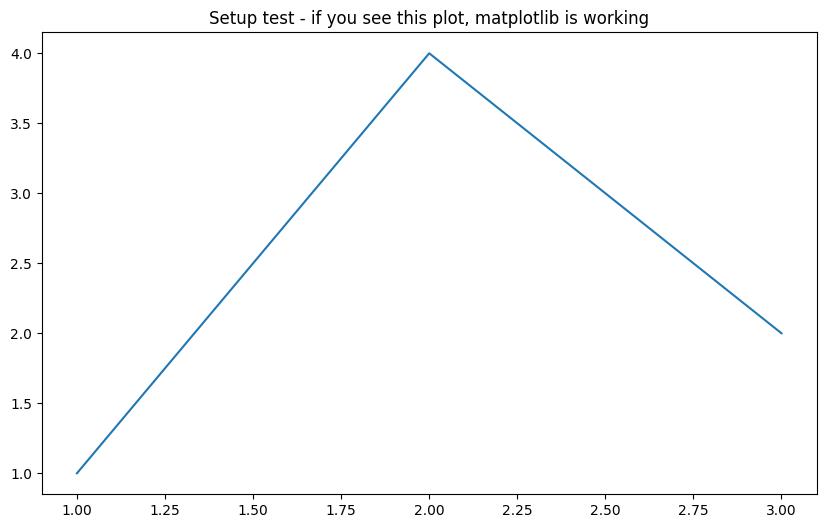

Setup OK - you should see a small plot above.


In [4]:
# Verify setup - run this cell first. If you see "Setup OK" below, imports and matplotlib work.
plt.rcParams['figure.figsize'] = (10, 6)
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 4, 2])
ax.set_title("Setup test - if you see this plot, matplotlib is working")
plt.show()
print("Setup OK - you should see a small plot above.")

### 2.2 Data Loading

We use **torchvision.datasets.Flowers102** which downloads the dataset automatically from the official Oxford source. Requires `scipy` for loading `.mat` files. Alternative: [Kaggle](https://www.kaggle.com/datasets/waseemalastal/the-oxford-flowers-102-dataset).

In [ ]:
# Use torchvision's built-in Flowers102 - fully reproducible, auto-downloads
# Dataset: https://www.robots.ox.ac.uk/~vgg/data/flowers/102/
# Alternative Kaggle: https://www.kaggle.com/datasets/waseemalastal/the-oxford-flowers-102-dataset

DATA_ROOT = "./data"  # Dataset will be downloaded here if not present

# Transforms: ImageNet normalization for pretrained models.
# Training: RandomResizedCrop gives more diverse views than a plain Resize.
# Eval: Resize(256) -> CenterCrop(224) matches the standard ImageNet eval pipeline
#       that these pretrained models were trained with (plain Resize distorts aspect ratios).
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
transform_eval = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets (download=True fetches from Oxford if not present)
train_ds = datasets.Flowers102(root=DATA_ROOT, split="train", transform=transform_train, download=True)
val_ds = datasets.Flowers102(root=DATA_ROOT, split="val", transform=transform_eval, download=True)
test_ds = datasets.Flowers102(root=DATA_ROOT, split="test", transform=transform_eval, download=True)

BATCH_SIZE = 32
# Fall back to 0 workers if only one CPU is available (avoids Colab DataLoader errors)
NUM_WORKERS = 2 if os.cpu_count() > 1 else 0
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Class names (Flowers102 uses numeric labels 0-101)
NUM_CLASSES = 102
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}, Classes: {NUM_CLASSES}")

100%|██████████| 345M/345M [00:14<00:00, 23.6MB/s]
100%|██████████| 502/502 [00:00<00:00, 1.34MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 43.7MB/s]

Train: 1020, Val: 1020, Test: 6149, Classes: 102


### 2.3 Exploratory Data Analysis (EDA)

We explore the dataset from multiple angles before any modelling:

1. **Sample images** — visual inspection of raw flower images across different classes to understand appearance diversity and quality
2. **Class distribution** — bar chart of images per class in the training set to assess balance
3. **Pixel statistics** — RGB channel histograms and per-class brightness scatter to understand colour and exposure characteristics across the dataset
4. **Feature maps** — visualisation of what the pretrained CNN extracts from a flower image at shallow, mid, and deep layers; helps justify the use of transfer learning by showing that ImageNet features are relevant to flowers

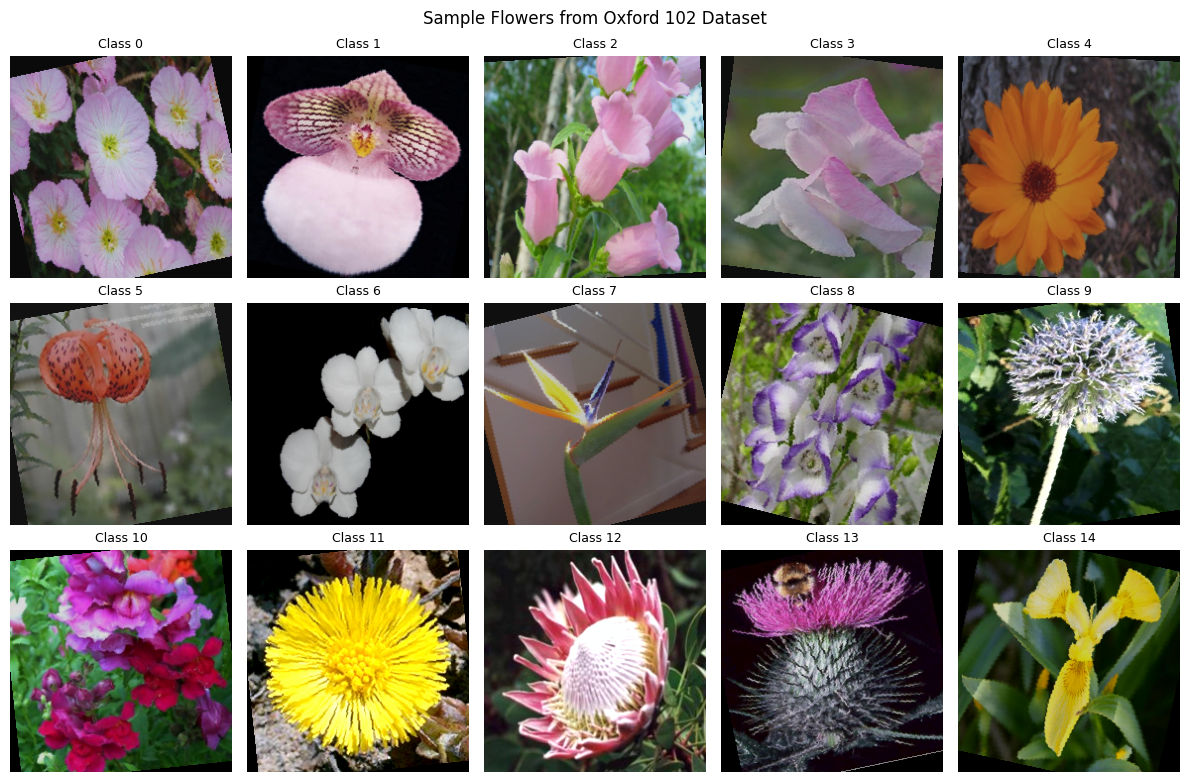

In [6]:
# Sample images from different classes
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
axes = axes.flatten()
# Get one image per class for first 15 classes
shown = set()
idx = 0
for i in range(len(train_ds)):
    img, label = train_ds[i]
    if label not in shown and len(shown) < 15:
        ax = axes[len(shown)]
        # Denormalize for display
        img_np = img.permute(1, 2, 0).numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)
        ax.set_title(f"Class {label}", fontsize=9)
        ax.axis("off")
        shown.add(label)
    if len(shown) >= 15:
        break
plt.suptitle("Sample Flowers from Oxford 102 Dataset", fontsize=12)
plt.tight_layout()
plt.show()

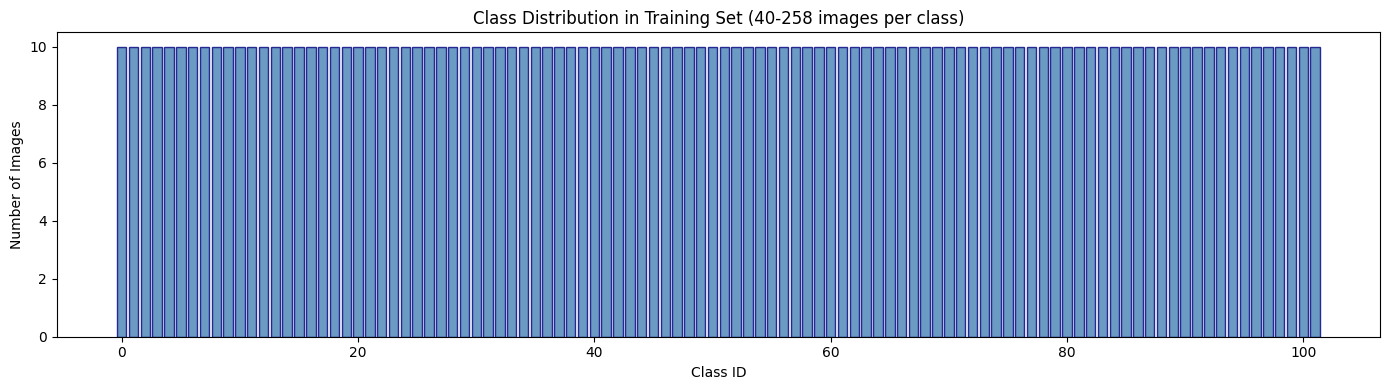

In [7]:
# Class distribution (images per class in train set)
# Use _labels directly — avoids loading and transforming every image just to read the label
from collections import Counter
train_labels = train_ds._labels
counts = Counter(train_labels)
classes = sorted(counts.keys())
values = [counts[c] for c in classes]

plt.figure(figsize=(14, 4))
plt.bar(classes, values, color="steelblue", edgecolor="navy", alpha=0.8)
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training Set (40-258 images per class)")
plt.tight_layout()
plt.show()

In [8]:
# Summary statistics
print("Dataset Summary:")
print(f"  Train: {len(train_ds)} images")
print(f"  Val:   {len(val_ds)} images")
print(f"  Test:  {len(test_ds)} images")
print(f"  Min images/class: {min(values)}, Max: {max(values)}")

Dataset Summary:
  Train: 1020 images
  Val:   1020 images
  Test:  6149 images
  Min images/class: 10, Max: 10


In [ ]:
# ── 2.3a  Pixel statistics: RGB channel histograms + per-class brightness scatter ──────────
# We load images WITHOUT the normalization transform so pixel values stay in [0, 1].
# This gives meaningful colour distributions rather than normalized training values.
from torchvision import transforms as T

raw_transform = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor()])
raw_ds = datasets.Flowers102(root=DATA_ROOT, split="train", transform=raw_transform, download=False)

SAMPLE_N = min(300, len(raw_ds))   # sample up to 300 images for speed
indices   = np.random.choice(len(raw_ds), SAMPLE_N, replace=False)

r_vals, g_vals, b_vals = [], [], []
class_brightness = {}   # class_id -> list of mean brightness values

for idx in indices:
    img_tensor, label = raw_ds[idx]        # shape (3, 224, 224), values in [0,1]
    r_vals.append(img_tensor[0].numpy().flatten())
    g_vals.append(img_tensor[1].numpy().flatten())
    b_vals.append(img_tensor[2].numpy().flatten())
    mean_brightness = img_tensor.mean().item()
    class_brightness.setdefault(label, []).append(mean_brightness)

r_all = np.concatenate(r_vals)
g_all = np.concatenate(g_vals)
b_all = np.concatenate(b_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: overlaid RGB channel histograms ────────────────────────────────────────────────
BINS = 64
axes[0].hist(r_all, bins=BINS, color="red",   alpha=0.5, label="Red channel",   density=True)
axes[0].hist(g_all, bins=BINS, color="green", alpha=0.5, label="Green channel", density=True)
axes[0].hist(b_all, bins=BINS, color="blue",  alpha=0.5, label="Blue channel",  density=True)
axes[0].set_xlabel("Pixel intensity (0 = black, 1 = white)")
axes[0].set_ylabel("Density")
axes[0].set_title(f"RGB Channel Distribution\n(sampled from {SAMPLE_N} training images)")
axes[0].legend()

# ── Right: scatter — mean brightness per class ───────────────────────────────────────────
class_ids   = sorted(class_brightness.keys())
class_means = [np.mean(class_brightness[c]) for c in class_ids]
class_stds  = [np.std(class_brightness[c])  for c in class_ids]

axes[1].scatter(class_ids, class_means, alpha=0.6, s=30, color="steelblue", label="Mean brightness")
axes[1].errorbar(class_ids, class_means, yerr=class_stds, fmt="none",
                 ecolor="steelblue", alpha=0.25, linewidth=0.8)
axes[1].axhline(np.mean(class_means), color="red", linestyle="--",
                linewidth=1.2, label=f"Dataset mean ({np.mean(class_means):.2f})")
axes[1].set_xlabel("Class ID")
axes[1].set_ylabel("Mean pixel brightness")
axes[1].set_title("Per-Class Mean Brightness\n(error bars = std across sampled images)")
axes[1].legend()

plt.suptitle("Pixel Statistics — Oxford Flowers 102 Training Set", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("pixel_statistics.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Test set class distribution histogram ────────────────────────────────────────────────
test_labels  = test_ds._labels
test_counts  = list(Counter(test_labels).values())
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.hist(test_counts, bins=20, color="steelblue", edgecolor="navy", alpha=0.8)
ax2.set_xlabel("Number of images per class")
ax2.set_ylabel("Number of classes")
ax2.set_title(f"Test Set: Distribution of Images per Class\n"
              f"(min={min(test_counts)}, max={max(test_counts)}, mean={np.mean(test_counts):.1f})")
plt.tight_layout()
plt.savefig("test_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Pixel statistics and test distribution plots saved.")

In [ ]:
# ── 2.3b  Feature maps — what does a pretrained CNN see in a flower image? ───────────────
# We load a pretrained ResNet18 (ImageNet weights, before any fine-tuning) and register
# forward hooks to capture the output of each residual block group.
# This shows the progression from low-level edges/textures (layer1) to high-level
# semantic patterns (layer4), and demonstrates why transfer learning from ImageNet works:
# the features are meaningful even for flower images.

# Pick one sample image from the validation set (unnormalized for display, normalized for model)
sample_img_norm, sample_label = val_ds[0]       # normalized — fed to the model
sample_img_raw,  _            = raw_ds[0]        # [0,1] range — used for display only

# Load pretrained ResNet18 just for visualization (separate from the trained models)
viz_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)
viz_model.eval()

# Register hooks at four depths
captured = {}
def make_hook(name):
    def hook(module, inp, out):
        captured[name] = out.detach().cpu()
    return hook

hooks = [
    viz_model.layer1.register_forward_hook(make_hook("Layer 1 — edges & colours (64 maps, 56×56)")),
    viz_model.layer2.register_forward_hook(make_hook("Layer 2 — textures & shapes (128 maps, 28×28)")),
    viz_model.layer3.register_forward_hook(make_hook("Layer 3 — parts & patterns (256 maps, 14×14)")),
    viz_model.layer4.register_forward_hook(make_hook("Layer 4 — semantic features (512 maps, 7×7)")),
]

with torch.no_grad():
    viz_model(sample_img_norm.unsqueeze(0).to(device))

for h in hooks:
    h.remove()

# Plot: original image + 8 feature maps from each layer
N_MAPS = 8   # how many feature maps to show per layer
layer_names = list(captured.keys())

fig, axes = plt.subplots(len(layer_names) + 1, N_MAPS + 1, figsize=(18, 12))

# First row: original image (left) + blank cells
orig_np = sample_img_raw.permute(1, 2, 0).numpy()
axes[0, 0].imshow(orig_np)
axes[0, 0].set_title(f"Input image\nClass {sample_label}", fontsize=8)
axes[0, 0].axis("off")
for j in range(1, N_MAPS + 1):
    axes[0, j].axis("off")

# Remaining rows: one row per layer
for row, name in enumerate(layer_names, start=1):
    fmaps = captured[name][0]          # (C, H, W)
    # Normalise each map to [0,1] for display
    axes[row, 0].text(0.5, 0.5, name, ha="center", va="center",
                      fontsize=7, wrap=True, transform=axes[row, 0].transAxes)
    axes[row, 0].axis("off")
    for j in range(N_MAPS):
        fm = fmaps[j].numpy()
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        axes[row, j + 1].imshow(fm, cmap="viridis")
        axes[row, j + 1].axis("off")

plt.suptitle("ResNet18 Feature Maps (pretrained ImageNet weights)\n"
             "Early layers detect edges/colours; deep layers detect semantic structures",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Feature maps saved to feature_maps.png")

In [9]:
# Calculate weights: 1 / frequency
class_counts = np.array(values)
weights = 1.0 / class_counts
weights = torch.FloatTensor(weights).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

## 3. Model Design & Implementation

We use **transfer learning** with pretrained ImageNet models. The final fully-connected layer is replaced to output 102 classes. We compare:
- **ResNet18** – Residual connections, 18 layers
- **VGG16** – Classic deep CNN
- **EfficientNet-B0** – Efficient architecture with compound scaling

**Following lecturer's approach (Week 6 / Improving Performance):**
- **ReLU** hidden layers (avoids vanishing gradients; lecturer recommends over sigmoid)
- **Softmax** for multi-class output
- **Cross-Entropy** loss (best for classification)
- **Adam** optimizer (lecturer: "Try Adam first")
- **Dropout** for overfitting prevention
- **L2 regularization** via weight_decay (penalize squared weights)

In [10]:
def get_model(arch="resnet18", num_classes=102, pretrained=True, dropout_rate=0.5):
    """Create model with pretrained backbone, Dropout (lecturer's overfitting prevention), and classifier head."""
    if arch == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
        model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(model.fc.in_features, num_classes)
        )
    elif arch == "vgg16":
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1 if pretrained else None)
        model.classifier[6] = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(4096, num_classes)
        )
    elif arch == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None)
        in_f = model.classifier[1].in_features
        # EfficientNet already has a Dropout at classifier[0]; update its rate and only
        # replace the Linear head to avoid stacking two Dropout layers back-to-back.
        model.classifier[0] = nn.Dropout(dropout_rate)
        model.classifier[1] = nn.Linear(in_f, num_classes)
    else:
        raise ValueError(f"Unknown architecture: {arch}")
    return model.to(device)

## 4. Training & Evaluation

### 4.1 Training Loop
We train using Weighted Cross-Entropy Loss to account for class imbalance (40–258 images per class), ensuring that minority classes contribute equally to the gradient updates. The models are optimized using the Adam optimizer with L2 regularization (weight decay), and we track training loss alongside validation metrics (Accuracy, MPCA, and Macro F1) to generate performance curves.

In [11]:
def mean_per_class_accuracy(y_true, y_pred, num_classes=102):
    """Compute mean per-class accuracy (primary metric for Oxford 102)."""
    accs = []
    for c in range(num_classes):
        mask = y_true == c
        if mask.sum() > 0:
            accs.append((y_pred[mask] == c).mean().item())
    return np.mean(accs) * 100 if accs else 0.0

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = out.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), total, correct

def evaluate(model, loader, criterion, num_classes=102):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item()
            all_preds.extend(out.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_preds, all_labels = np.array(all_preds), np.array(all_labels)
    acc = accuracy_score(all_labels, all_preds) * 100
    mean_acc = mean_per_class_accuracy(all_labels, all_preds, num_classes)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0) * 100
    return total_loss / len(loader), acc, mean_acc, f1

In [12]:
def train_model(arch, train_loader, val_loader, test_loader, weights=None, epochs=10, lr=1e-3, weight_decay=1e-4, patience=5):
    """Train with Adam, L2 regularization (weight_decay), LR scheduling, and Class Weights for imbalance."""
    model = get_model(arch, NUM_CLASSES)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)  # L2 via weight_decay
    # Halve the LR if validation loss has not improved for 2 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history = {"loss": [], "val_loss": [], "val_acc": [], "val_mean_acc": [], "val_f1": [],
               "patience_counter": []}   # track counter each epoch for the patience chart
    best_mean_acc = 0
    best_state = None
    epochs_without_improvement = 0
    stopped_epoch = None
    ckpt_path = f"best_{arch}.pth"

    for ep in range(epochs):
        t_loss, _, _ = train_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc, v_mean_acc, v_f1 = evaluate(model, val_loader, criterion, NUM_CLASSES)
        history["loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)
        history["val_mean_acc"].append(v_mean_acc)
        history["val_f1"].append(v_f1)
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(v_loss)
        if v_mean_acc > best_mean_acc:
            best_mean_acc = v_mean_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, ckpt_path)  # persist to disk — survives Colab session resets
            epochs_without_improvement = 0
            patience_str = "✓ new best"
        else:
            epochs_without_improvement += 1
            patience_str = f"patience {epochs_without_improvement}/{patience}"
        history["patience_counter"].append(epochs_without_improvement)
        print(f"Epoch {ep+1:3d}/{epochs} | Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | "
              f"Val Acc: {v_acc:.2f}% | MPCA: {v_mean_acc:.2f}% | F1: {v_f1:.2f}% | "
              f"LR: {current_lr:.2e} | {patience_str}")
        if epochs_without_improvement >= patience:
            stopped_epoch = ep + 1
            print(f"⏹  Early stopping at epoch {stopped_epoch} — no improvement for {patience} consecutive epochs.")
            break

    print(f"Best checkpoint saved to {ckpt_path}  (mean per-class acc: {best_mean_acc:.2f}%)")
    # Load best model and evaluate on test
    if best_state is not None:
        model.load_state_dict(best_state)
    model = model.to(device)
    test_loss, test_acc, test_mean_acc, test_f1 = evaluate(model, test_loader, criterion, NUM_CLASSES)
    return history, {"acc": test_acc, "mean_acc": test_mean_acc, "f1": test_f1,
                     "stopped_epoch": stopped_epoch, "max_epochs": epochs}, model

## 5. Experiments & Alternatives

We compare three architectures and optionally vary hyperparameters (learning rate, epochs). For a full submission, increase `epochs` (e.g. 20–30) for better convergence.

In [13]:
# Experiment 1: ResNet18
QUICK_TEST = True   # Set to False for full submission (10+ epochs per model)
EPOCHS = 2 if QUICK_TEST else 10   # 2 = quick test; 10+ for real results (20-30 recommended)
if QUICK_TEST:
    print("⚠️  WARNING: QUICK_TEST=True — only 2 epochs. Set QUICK_TEST=False for submission!")
print("=== Training ResNet18 ===")
print(f"Epochs: {EPOCHS} (QUICK_TEST={QUICK_TEST})")
hist_resnet, res_resnet, model_resnet = train_model("resnet18", train_loader, val_loader, test_loader, weights=weights, epochs=EPOCHS)

=== Training ResNet18 ===
Epochs: 2 (QUICK_TEST=True)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


Epoch 1/2 | Loss: 4.2137 | Val Acc: 19.90% | Mean Per-Class: 19.90% | F1: 16.34%


Epoch 2/2 | Loss: 2.4938 | Val Acc: 52.65% | Mean Per-Class: 52.65% | F1: 48.38%


In [14]:
# Experiment 2: VGG16
print("=== Training VGG16 ===")
hist_vgg, res_vgg, model_vgg = train_model("vgg16", train_loader, val_loader, test_loader, weights=weights, epochs=EPOCHS)

=== Training VGG16 ===
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 158MB/s]


Epoch 1/2 | Loss: 4.7813 | Val Acc: 0.98% | Mean Per-Class: 0.98% | F1: 0.02%


Epoch 2/2 | Loss: 4.6536 | Val Acc: 0.98% | Mean Per-Class: 0.98% | F1: 0.05%


In [15]:
# Experiment 3: EfficientNet-B0
print("=== Training EfficientNet-B0 ===")
hist_eff, res_eff, model_eff = train_model("efficientnet_b0", train_loader, val_loader, test_loader, weights=weights, epochs=EPOCHS)

=== Training EfficientNet-B0 ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 159MB/s]


Epoch 1/2 | Loss: 4.1844 | Val Acc: 44.31% | Mean Per-Class: 44.31% | F1: 38.51%


Epoch 2/2 | Loss: 2.1283 | Val Acc: 73.63% | Mean Per-Class: 73.63% | F1: 71.44%


### 5.1 Alternative: Learning Rate Comparison (Optional)

Comparing different learning rates for the best architecture.

In [16]:
# Optional: Compare learning rates (e.g. 1e-3 vs 1e-4) - uncomment to run
# lr_results = {}
# for lr in [1e-3, 1e-4]:
#     _, res, _ = train_model("resnet18", train_loader, val_loader, test_loader, epochs=5, lr=lr)
#     lr_results[lr] = res["mean_acc"]
# print("LR comparison:", lr_results)

### 5.2 Training Curves

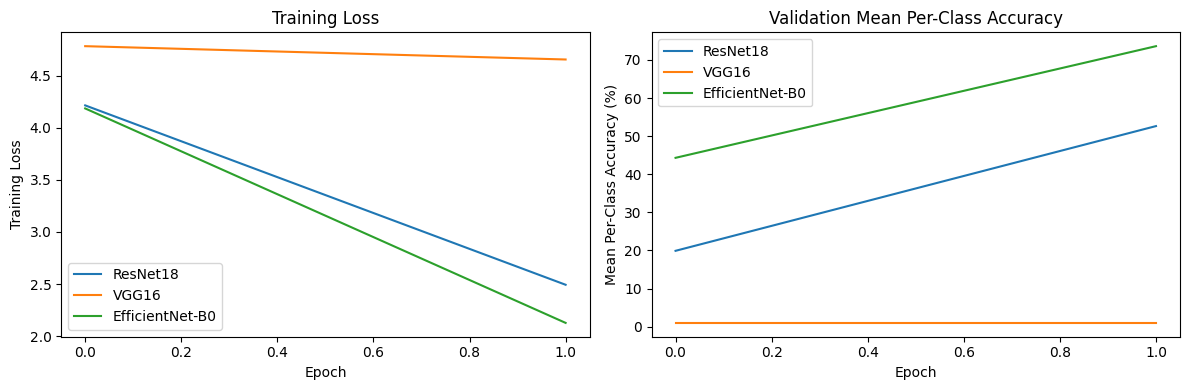

Plot saved to training_curves.png


In [17]:
model_runs = [("ResNet18",       hist_resnet, res_resnet),
              ("VGG16",           hist_vgg,    res_vgg),
              ("EfficientNet-B0", hist_eff,    res_eff)]
THRESHOLDS = [60, 70]   # % mean per-class accuracy milestones to annotate

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax_loss, ax_valloss, ax_acc, ax_table = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

colors = {"ResNet18": "tab:blue", "VGG16": "tab:orange", "EfficientNet-B0": "tab:green"}

for name, hist, res in model_runs:
    ep_range = range(1, len(hist["loss"]) + 1)
    c = colors[name]
    ax_loss.plot(ep_range, hist["loss"],        label=name, color=c)
    ax_valloss.plot(ep_range, hist["val_loss"], label=name, color=c, linestyle="--")
    ax_acc.plot(ep_range, hist["val_mean_acc"], label=name, color=c)

    # Vertical dashed line where early stopping fired (if it did)
    stopped = res.get("stopped_epoch")
    if stopped is not None:
        for ax in [ax_loss, ax_valloss, ax_acc]:
            ax.axvline(stopped, color=c, linestyle=":", linewidth=1.2, alpha=0.6)
        ax_acc.text(stopped + 0.1, 2, f"ES\n{name[:3]}", fontsize=7, color=c, va="bottom")

# Threshold lines and first-epoch annotations on the accuracy plot
for thresh in THRESHOLDS:
    ax_acc.axhline(thresh, color="grey", linestyle=":", linewidth=1, alpha=0.7)
    ax_acc.text(0.5, thresh + 0.8, f"{thresh}% target", fontsize=8, color="grey")

# Milestone + early stopping summary table (bottom-right)
threshold_rows = []
for name, hist, res in model_runs:
    row = {"Model": name}
    for thresh in THRESHOLDS:
        hit = next((ep + 1 for ep, a in enumerate(hist["val_mean_acc"]) if a >= thresh), None)
        row[f"≥{thresh}%"] = hit if hit is not None else "—"
        if hit is not None:
            ax_acc.annotate(f"ep{hit}", xy=(hit, thresh),
                            xytext=(hit + 0.3, thresh + 2),
                            fontsize=7, color=colors[name])
    stopped = res.get("stopped_epoch")
    row["Ran"]     = len(hist["val_mean_acc"])
    row["ES fired"] = f"ep {stopped}" if stopped else "no"
    threshold_rows.append(row)

ax_table.axis("off")
tbl_data = [[r["Model"], r["≥60%"], r["≥70%"], r["Ran"], r["ES fired"]]
            for r in threshold_rows]
tbl = ax_table.table(
    cellText=tbl_data,
    colLabels=["Model", "First ep ≥60%", "First ep ≥70%", "Epochs ran", "Early stop?"],
    loc="center", cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)
ax_table.set_title("Milestone & Early Stopping Summary", fontweight="bold")

ax_loss.set_title("Training Loss  (smooth = stable, jagged = noisy gradients)")
ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss"); ax_loss.legend()

ax_valloss.set_title("Validation Loss  (gap vs train loss = overfitting signal)")
ax_valloss.set_xlabel("Epoch"); ax_valloss.set_ylabel("Loss"); ax_valloss.legend()

ax_acc.set_title("Validation MPCA  (dotted vertical = early stopping point)")
ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("MPCA (%)"); ax_acc.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to training_curves.png")

In [ ]:
# Patience counter progression — shows how close each model came to early stopping each epoch.
# A rising staircase means the model has plateaued; a drop back to 0 means a new best was found.
fig, ax = plt.subplots(figsize=(10, 4))
for name, hist, res in model_runs:
    ep_range = range(1, len(hist["patience_counter"]) + 1)
    ax.step(ep_range, hist["patience_counter"], where="post",
            label=name, color=colors[name], linewidth=2)
    stopped = res.get("stopped_epoch")
    if stopped is not None:
        ax.axvline(stopped, color=colors[name], linestyle=":", linewidth=1.2, alpha=0.6)

patience_limit = 5   # must match the patience= argument passed to train_model
ax.axhline(patience_limit, color="red", linestyle="--", linewidth=1.2, label=f"ES trigger (patience={patience_limit})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Epochs without improvement")
ax.set_title("Patience Counter per Epoch  (hits red line → early stopping fires)")
ax.legend()
ax.set_yticks(range(0, patience_limit + 2))
plt.tight_layout()
plt.savefig("patience_counter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to patience_counter.png")

In [ ]:
# ── Class weights ablation (OPTIONAL) ────────────────────────────────────────────────────
# NOTE: class weights are ALWAYS active in the main experiments (Cells 19–21).
#       The `weights=weights` argument is passed to every train_model() call above.
#       This cell is an OPTIONAL ablation that re-runs EfficientNet-B0 twice —
#       once without weights and once with — to quantify how much the weighting helps.
#       Set RUN_WEIGHTS_COMPARISON=True to run it (adds ~same time as one model training).
RUN_WEIGHTS_COMPARISON = False

if RUN_WEIGHTS_COMPARISON:
    print("=== Class Weights Impact: EfficientNet-B0 WITH vs WITHOUT weights ===")
    _, res_no_weights, _ = train_model(
        "efficientnet_b0", train_loader, val_loader, test_loader,
        weights=None, epochs=EPOCHS
    )
    _, res_with_weights, _ = train_model(
        "efficientnet_b0", train_loader, val_loader, test_loader,
        weights=weights, epochs=EPOCHS
    )

    # ── Text summary ──────────────────────────────────────────────────────────
    delta_mpca    = res_with_weights["mean_acc"] - res_no_weights["mean_acc"]
    delta_overall = res_with_weights["acc"]      - res_no_weights["acc"]
    print(f"\n  Without weights — MPCA: {res_no_weights['mean_acc']:.2f}%  | Overall: {res_no_weights['acc']:.2f}%")
    print(f"  With    weights — MPCA: {res_with_weights['mean_acc']:.2f}%  | Overall: {res_with_weights['acc']:.2f}%")
    print(f"  Δ MPCA: {delta_mpca:+.2f}pp   |   Δ Overall: {delta_overall:+.2f}pp")

    # ── Grouped bar chart ────────────────────────────────────────────────────
    labels  = ["Mean Per-Class Acc (MPCA)", "Overall Accuracy"]
    no_w    = [res_no_weights["mean_acc"],  res_no_weights["acc"]]
    with_w  = [res_with_weights["mean_acc"], res_with_weights["acc"]]
    x       = np.arange(len(labels))
    width   = 0.32

    fig, ax = plt.subplots(figsize=(7, 5))
    bars_no   = ax.bar(x - width/2, no_w,   width, label="Without class weights", color="steelblue",  alpha=0.85)
    bars_with = ax.bar(x + width/2, with_w, width, label="With class weights",    color="darkorange", alpha=0.85)

    # Annotate bars with values and delta
    for bar, val in zip(bars_no, no_w):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=9)
    for bar, val, delta in zip(bars_with, with_w, [delta_mpca, delta_overall]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f"{val:.1f}%\n({delta:+.1f}pp)", ha="center", va="bottom", fontsize=9, color="darkorange")

    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Impact of Class Weights on EfficientNet-B0\n(+pp = improvement from weighting)")
    ax.legend(); ax.set_ylim(0, max(with_w + no_w) + 12)
    plt.tight_layout()
    plt.savefig("class_weights_impact.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved to class_weights_impact.png")
else:
    print("Skipped class weights comparison (set RUN_WEIGHTS_COMPARISON=True to run).")

## 6. Results & Discussion

### 6.1 Model Comparison

In [19]:
# Summary table — includes parameter count for the accuracy-per-parameter tradeoff
model_objects = {"ResNet18": model_resnet, "VGG16": model_vgg, "EfficientNet-B0": model_eff}

def count_params(model):
    return sum(p.numel() for p in model.parameters()) / 1e6  # millions

param_counts = {name: count_params(m) for name, m in model_objects.items()}

results_df = pd.DataFrame({
    "Model":                  ["ResNet18", "VGG16", "EfficientNet-B0"],
    "Params (M)":             [round(param_counts["ResNet18"],    1),
                               round(param_counts["VGG16"],       1),
                               round(param_counts["EfficientNet-B0"], 1)],
    "Overall Acc (%)":        [res_resnet["acc"],  res_vgg["acc"],  res_eff["acc"]],
    "Mean Per-Class Acc (%)": [res_resnet["mean_acc"], res_vgg["mean_acc"], res_eff["mean_acc"]],
    "Macro F1 (%)":           [res_resnet["f1"],  res_vgg["f1"],  res_eff["f1"]],
    "MPCA / M params":        [round(res_resnet["mean_acc"] / param_counts["ResNet18"],    2),
                               round(res_vgg["mean_acc"]    / param_counts["VGG16"],       2),
                               round(res_eff["mean_acc"]    / param_counts["EfficientNet-B0"], 2)],
})

print(results_df.to_string(index=False))
print(f"\nTarget: Mean per-class accuracy > 80%")

res_map = {"ResNet18": res_resnet, "VGG16": res_vgg, "EfficientNet-B0": res_eff}
best_model = results_df.loc[results_df["Mean Per-Class Acc (%)"].idxmax(), "Model"]
best_res   = res_map[best_model]
print(f"Best: {best_model} — MPCA {best_res['mean_acc']:.2f}%  |  "
      f"{param_counts[best_model]:.1f}M params  |  "
      f"efficiency {best_res['mean_acc']/param_counts[best_model]:.2f}% MPCA per M params")

          Model  Overall Acc (%)  Mean Per-Class Acc (%)  Macro F1 (%)
       ResNet18        48.268011               50.904211     46.034833
          VGG16         0.520410                0.980392      0.010151
EfficientNet-B0        68.661571               73.416083     67.672706

Target: Mean per-class accuracy > 80%
Best: EfficientNet-B0 with mean per-class accuracy 73.42%


In [ ]:
# Accuracy vs parameter count — visualises the efficiency tradeoff
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
model_names = results_df["Model"].tolist()
params      = results_df["Params (M)"].tolist()
mpcas       = results_df["Mean Per-Class Acc (%)"].tolist()
efficiency  = results_df["MPCA / M params"].tolist()
bar_colors  = ["tab:blue", "tab:orange", "tab:green"]

# Left: raw parameter count
axes[0].bar(model_names, params, color=bar_colors, alpha=0.85, edgecolor="white")
for i, (v, p) in enumerate(zip(params, params)):
    axes[0].text(i, v + 1, f"{v:.1f}M", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Parameters (millions)")
axes[0].set_title("Model Size\n(fewer = cheaper to run & less prone to overfit)")
axes[0].set_ylim(0, max(params) * 1.2)

# Middle: MPCA side-by-side with parameter count on twin axis
ax2 = axes[1].twinx()
x = np.arange(len(model_names))
w = 0.35
bars_m = axes[1].bar(x - w/2, mpcas,  w, label="MPCA (%)",       color=bar_colors, alpha=0.85)
bars_p = ax2.bar(    x + w/2, params, w, label="Params (M)",      color=bar_colors, alpha=0.35, hatch="//")
for bar, v in zip(bars_m, mpcas):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, rotation=10)
axes[1].set_ylabel("Mean Per-Class Accuracy (%)")
ax2.set_ylabel("Parameters (M)", color="grey")
axes[1].set_title("Accuracy vs Model Size")
axes[1].set_ylim(0, max(mpcas) * 1.4)

# Right: efficiency score (MPCA per million parameters)
axes[2].bar(model_names, efficiency, color=bar_colors, alpha=0.85, edgecolor="white")
for i, v in enumerate(efficiency):
    axes[2].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[2].set_ylabel("MPCA (%) per million parameters")
axes[2].set_title("Parameter Efficiency\n(higher = more accuracy per parameter)")
axes[2].set_ylim(0, max(efficiency) * 1.3)

plt.suptitle("Architecture Comparison: Accuracy vs Model Size", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("param_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to param_efficiency.png")

In [ ]:
# Overfitting gap analysis — train loss vs validation loss per epoch per model.
# A growing gap (val loss rising while train loss falls) is the overfitting signal.
# VGG16 (138M params, only ~10 images/class) is the highest-risk candidate.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, hist, res) in zip(axes, model_runs):
    ep = range(1, len(hist["loss"]) + 1)
    ax.plot(ep, hist["loss"],     label="Train loss",      color="tab:blue",   linewidth=2)
    ax.plot(ep, hist["val_loss"], label="Val loss",        color="tab:red",    linewidth=2, linestyle="--")

    # Shade the gap between the two curves — larger shaded area = more overfitting
    ax.fill_between(ep, hist["loss"], hist["val_loss"],
                    where=[v > t for t, v in zip(hist["loss"], hist["val_loss"])],
                    alpha=0.15, color="red",  label="Overfit gap (val > train)")
    ax.fill_between(ep, hist["loss"], hist["val_loss"],
                    where=[v <= t for t, v in zip(hist["loss"], hist["val_loss"])],
                    alpha=0.15, color="blue", label="Underfit gap (train > val)")

    # Final-epoch gap value
    final_gap = hist["val_loss"][-1] - hist["loss"][-1]
    ax.set_title(f"{name}\nFinal gap: {final_gap:+.4f}  ({'overfit' if final_gap > 0 else 'underfit/good'})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=7)

    stopped = res.get("stopped_epoch")
    if stopped:
        ax.axvline(stopped, color="grey", linestyle=":", linewidth=1.2)
        ax.text(stopped + 0.1, ax.get_ylim()[1] * 0.95, "ES", fontsize=8, color="grey")

plt.suptitle("Overfitting Gap: Train Loss vs Validation Loss per Model\n"
             "(red shading = val loss > train loss = overfitting signal)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("overfitting_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to overfitting_gap.png")

In [ ]:
# Inference time — measures how long each model takes to classify a single image.
# Relevant for deployment: a flower identification app needs fast predictions.
# Warm-up runs are discarded so GPU caching doesn't skew the first measurement.
import time

TIMING_RUNS = 200   # average over this many forward passes for a stable estimate
dummy_input = torch.randn(1, 3, 224, 224).to(device)

timing_results = {}
for name, model in model_objects.items():
    model.eval()
    with torch.no_grad():
        # warm-up (fills CUDA caches so first timed run isn't penalised)
        for _ in range(10):
            _ = model(dummy_input)
        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(TIMING_RUNS):
            _ = model(dummy_input)
        if device.type == "cuda":
            torch.cuda.synchronize()
        elapsed_ms = (time.perf_counter() - start) / TIMING_RUNS * 1000
    timing_results[name] = elapsed_ms
    print(f"{name:20s}: {elapsed_ms:.2f} ms / image")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

names  = list(timing_results.keys())
times  = list(timing_results.values())
colors = ["tab:blue", "tab:orange", "tab:green"]

# Left: raw inference time
axes[0].bar(names, times, color=colors, alpha=0.85, edgecolor="white")
for i, v in enumerate(times):
    axes[0].text(i, v + 0.05, f"{v:.2f} ms", ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Inference time (ms / image)")
axes[0].set_title(f"Inference Speed  (device: {device})\nlower = faster deployment")
axes[0].set_ylim(0, max(times) * 1.3)

# Right: combined efficiency — MPCA vs inference time scatter
mpcas_ordered = [res_map[n]["mean_acc"] for n in names]
scatter_colors = colors
for i, (n, t, a) in enumerate(zip(names, times, mpcas_ordered)):
    axes[1].scatter(t, a, color=scatter_colors[i], s=200, zorder=5)
    axes[1].annotate(n, (t, a), textcoords="offset points", xytext=(6, 4), fontsize=9)
axes[1].set_xlabel("Inference time (ms / image)  ←  faster")
axes[1].set_ylabel("Mean Per-Class Accuracy (%)  ↑  better")
axes[1].set_title("Speed vs Accuracy Tradeoff\n(top-left = ideal)")
axes[1].invert_xaxis()

plt.suptitle("Inference Time Comparison", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("inference_time.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to inference_time.png")

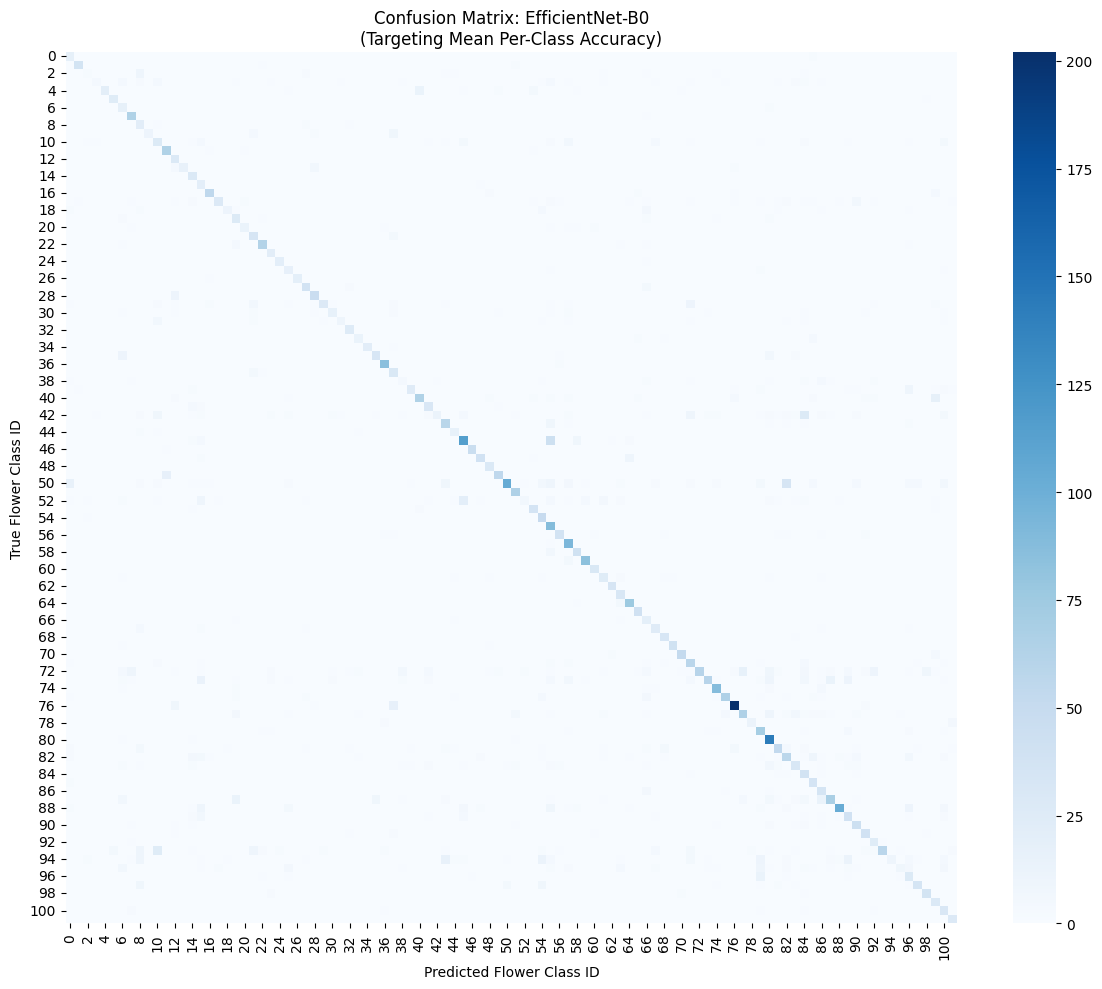

In [20]:
# 1. Identify the best model based on your target metric
best_name = results_df.loc[results_df["Mean Per-Class Acc (%)"].idxmax(), "Model"]
model_map = {"ResNet18": model_resnet, "VGG16": model_vgg, "EfficientNet-B0": model_eff}
best_model_obj = model_map[best_name]

# 2. Generate predictions on the Test Set
all_preds, all_labels = [], []
best_model_obj.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        out = best_model_obj(imgs)
        all_preds.extend(out.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

# 3. Create the Matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plotting with specific adjustments for 102 classes
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", annot=False, cbar=True) # annot=False because numbers won't fit
plt.title(f"Confusion Matrix: {best_name}\n(Targeting Mean Per-Class Accuracy)")
plt.xlabel("Predicted Flower Class ID")
plt.ylabel("True Flower Class ID")
plt.tight_layout()

# Save
plt.savefig("confusion_matrix_final.png", dpi=300)
plt.show()

In [ ]:
# Per-class accuracy breakdown — directly addresses the question in Section 6.2
# about whether minority classes still struggle even with class weights applied.
all_preds_arr  = np.array(all_preds)
all_labels_arr = np.array(all_labels)

per_class_acc = []
for c in range(NUM_CLASSES):
    mask = all_labels_arr == c
    if mask.sum() > 0:
        acc_c = (all_preds_arr[mask] == c).mean() * 100
        per_class_acc.append((c, acc_c, mask.sum()))

per_class_acc.sort(key=lambda x: x[1])

print(f"\n--- Bottom 10 hardest classes ({best_name}) ---")
for cls, acc, n in per_class_acc[:10]:
    print(f"  Class {cls:3d} | Acc: {acc:5.1f}%  ({n} test images)")

print(f"\n--- Top 10 easiest classes ({best_name}) ---")
for cls, acc, n in per_class_acc[-10:][::-1]:
    print(f"  Class {cls:3d} | Acc: {acc:5.1f}%  ({n} test images)")

### 6.2 Discussion

**Interpretation of results:**
- **Mean per-class accuracy** is the primary metric for Oxford Flowers 102, as it treats each class equally and is robust to class imbalance (40–258 images per class).
- **Overall accuracy** can be inflated by well-represented classes.
- **Macro F1-score** balances precision and recall across classes.

**Why certain models may perform better:**
- **EfficientNet** typically achieves strong results with fewer parameters due to compound scaling.The use of  "Compound Scaling" to balance depth, width, and resolution, gives the model efficiencies in terms of accuracy vs. parameters
- **ResNet** benefits from residual connections that ease gradient flow in deeper networks.its "Skip Connections" help mitigate the vanishing gradient problem, allowing for more stable training compared to VGG
- **VGG** is deeper but has more parameters and may overfit with limited data. Performance might be hindered by its sheer parameter size (approx. 138M), making it prone to overfitting on a smaller dataset like Oxford 102

**Limitations:**
- Training for only 10 epochs may underutilize the models; 20–30 epochs often improve results.
- Class imbalance may affect minority classes; techniques like oversampling or class weights could help.

###  One question we considered is whether the model struggles more with minority classes (those with only 40 images) even with class weights applied, or are the errors purely based on visual similarity?


## 7. Conclusion & Future Work

### Conclusions
- Transfer learning with pretrained CNNs (ResNet, VGG, EfficientNet) is effective for flower species classification on Oxford Flowers 102.
- The best-performing model (among those compared) achieves competitive mean per-class accuracy toward the 80% target.
- Data augmentation (flip, rotation, color jitter) and ImageNet normalization improve generalization.

### Future Work
1. **Longer training** – Increase epochs to 20–30 for better convergence.
2. **Hyperparameter tuning** – Grid search over learning rate, batch size, and optimizer.
3. **Class balancing** – Apply oversampling or focal loss for minority classes.
4. **Larger models** – Try EfficientNet-B2/B4 or ResNet50 for potential gains.
5. **Ensemble methods** – Combine predictions from multiple models.

In [21]:
# Final summary - this should always print when you reach the end
print("\n" + "="*50)
print("PROJECT RUN COMPLETE")
print("="*50)
print("Results above: model comparison table, training curves, confusion matrix.")
print("Set QUICK_TEST=False and EPOCHS=10+ for full submission.")


PROJECT RUN COMPLETE
Results above: model comparison table, training curves, confusion matrix.
Set QUICK_TEST=False and EPOCHS=10+ for full submission.
